In [1]:
import pandas as pd
data=pd.read_csv("Real estate.csv")

In [2]:
data.shape

(414, 8)

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


In [4]:
data.isna().sum()

No                                        0
X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64

In [5]:
data.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [6]:
encoded_data = pd.get_dummies(data,dtype=int)

In [7]:
data.duplicated().sum()

np.int64(0)

In [8]:
encoded_data.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [9]:
X = encoded_data.drop('Y house price of unit area', axis=1)
y = encoded_data['Y house price of unit area']               

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [11]:
from sklearn.linear_model import LinearRegression
Area_predict=LinearRegression()
Area_predict.fit(X_train, y_train)

LinearRegression()

In [12]:
Area_predict.coef_

array([-6.25951905e-03,  5.85978276e+00, -2.39516367e-01, -5.22951335e-03,
        1.06493330e+00,  2.36128176e+02, -5.44687080e+01])

In [13]:
Area_predict.intercept_

np.float64(-11027.885203810616)

In [14]:
from sklearn.metrics import mean_squared_error, r2_score
y_pred_train = Area_predict.predict(X_train)
train_error = mean_squared_error(y_train, y_pred_train)
train_r2 = r2_score(y_train, y_pred_train)

In [15]:
train_r2

0.5888965057262849

In [16]:
train_error

78.74157321401154

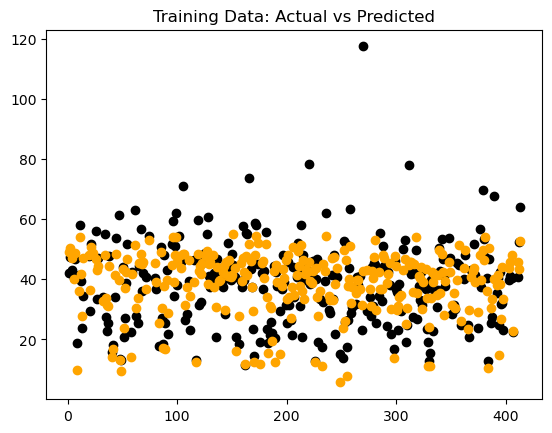

In [28]:
import matplotlib.pyplot as plt
plt.figure()
plt.scatter(x=X_train.index,y=y_train,color="black")
plt.scatter(x=X_train.index,y=y_pred_train,color="orange")
plt.title("Training Data: Actual vs Predicted")
plt.savefig("plot.png")
plt.show()

In [19]:
y_pred_test = Area_predict.predict(X_test)
test_error = mean_squared_error(y_test, y_pred_test)
test_r2 = r2_score(y_test, y_pred_test)

In [20]:
test_error

74.70865668115482

In [21]:
test_r2

0.5532450005316545

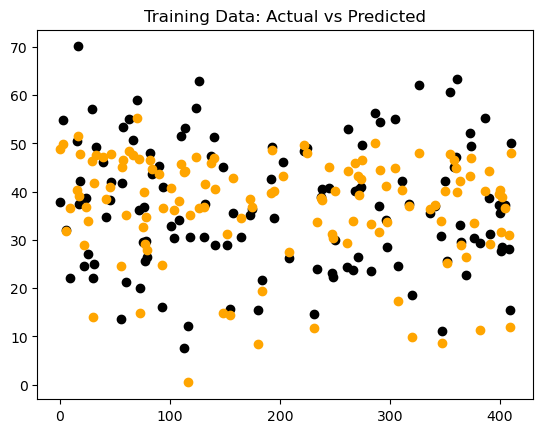

In [30]:
import matplotlib.pyplot as plt
plt.figure()
plt.scatter(x=X_test.index,y=y_test,color="black")
plt.scatter(x=X_test.index,y=y_pred_test,color="orange")
plt.title("Training Data: Actual vs Predicted")
plt.savefig("plot.png")
plt.show()

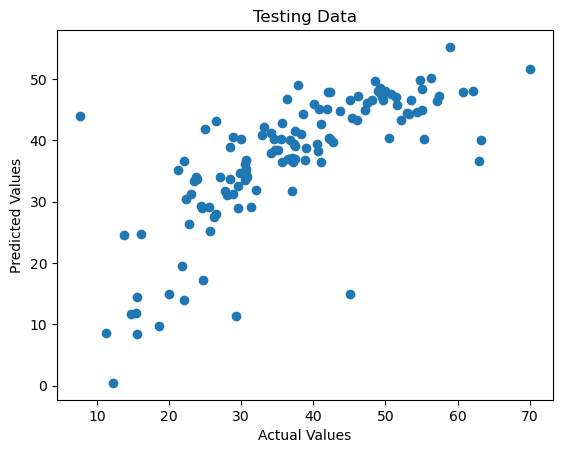

In [24]:
plt.figure()
plt.scatter(y_test, y_pred_test)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Testing Data")
plt.show()